In [2]:
import pandas as pd
import dataset

<https://www.extremeweatherwatch.com/cities/new-york/year-2024>

In [3]:
wthr = pd.read_csv("../../data/nyc_weather_2024.csv")
wthr['date'] = pd.to_datetime(wthr['Day'] + ' 2024', format='%B %d %Y')
wthr = wthr.drop(columns='Day')
wthr

,High,Low,Precip,Snow,date
0,47,35,0.03,0.0,2024-01-01
1,42,29,0.00,0.0,2024-01-02
2,43,34,0.00,0.0,2024-01-03
3,45,28,0.00,0.0,2024-01-04
4,37,26,0.00,0.0,2024-01-05
...,...,...,...,...,...
361,44,26,0.00,0.0,2024-12-27
362,54,40,0.56,0.0,2024-12-28
363,60,50,0.16,0.0,2024-12-29
364,58,49,0.37,0.0,2024-12-30


In [18]:
df = dataset.read_agg(month_start=1, month_end=12)

In [19]:

df['pickup_date'] = pd.to_datetime(
    df[['pickup_year', 'pickup_month', 'pickup_day']].rename(columns={
        'pickup_year': 'year', 
        'pickup_month':'month',
        'pickup_day': 'day'
}))
df = pd.merge(df, wthr, left_on='pickup_date', right_on='date', how='left')
df = df.drop(columns=['date'])
df["is_weekend"] = df["pickup_dow"].isin([5, 6]).astype(int) 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2887842 entries, 0 to 2887841
Data columns (total 39 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   pickup_year            int32         
 1   pickup_month           int32         
 2   pickup_week            UInt32        
 3   pickup_day             int32         
 4   pickup_dow             int32         
 5   pickup_service_zone    category      
 6   pickup_zone            object        
 7   dropoff_service_zone   category      
 8   dropoff_zone           object        
 9   route                  object        
 10  service_route          category      
 11  vendor                 object        
 12  total_ride_count       int64         
 13  total_passenger_count  float64       
 14  avg_passenger_count    float64       
 15  total_trip_distance    float64       
 16  avg_trip_distance      float64       
 17  total_fare_amount      float64       
 18  avg_fare_amount       

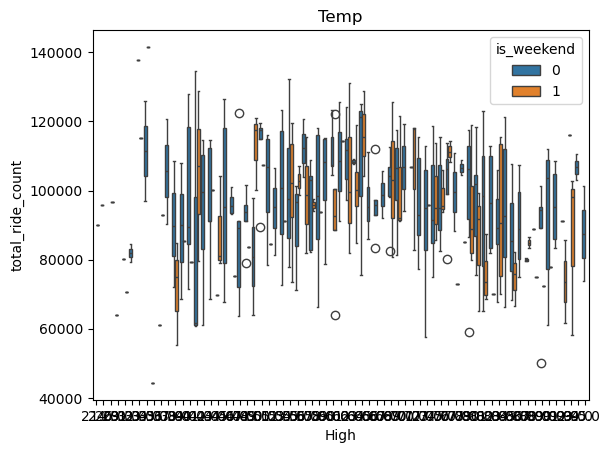

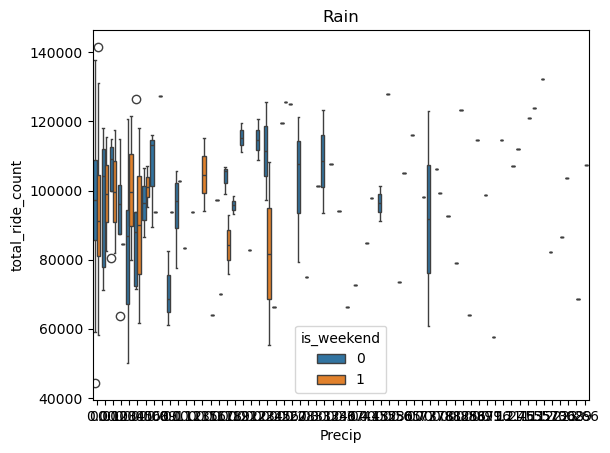

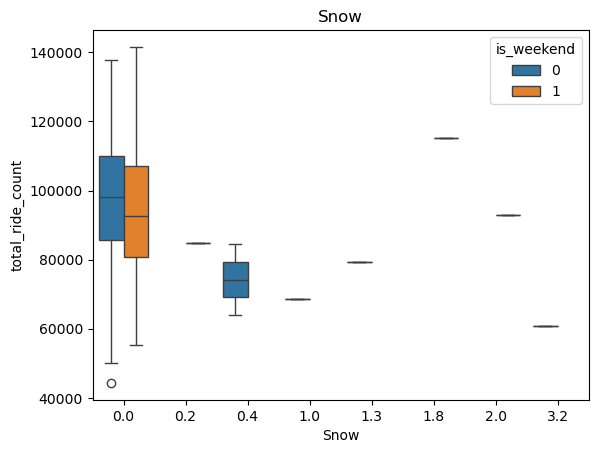

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

daily = df.groupby(by=['pickup_date', 'is_weekend'], as_index=False).agg({
    'total_ride_count': 'sum'
})
daily = pd.merge(daily, wthr, left_on='pickup_date', right_on='date', how='left')
daily

sns.boxplot(data=daily, x='High', y='total_ride_count', hue='is_weekend')
plt.title("Temp")
plt.show()

sns.boxplot(data=daily, x='Precip', y='total_ride_count', hue='is_weekend')
plt.title("Rain")
plt.show()

sns.boxplot(data=daily, x='Snow', y='total_ride_count', hue='is_weekend')
plt.title("Snow")
plt.show()

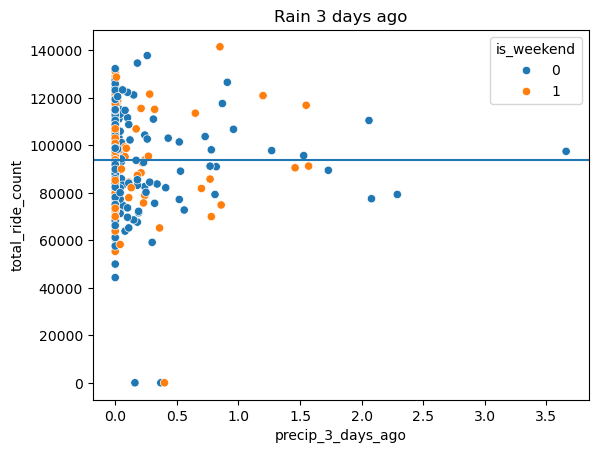

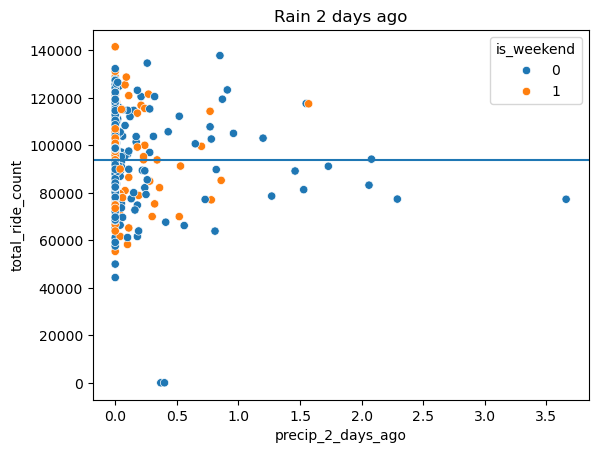

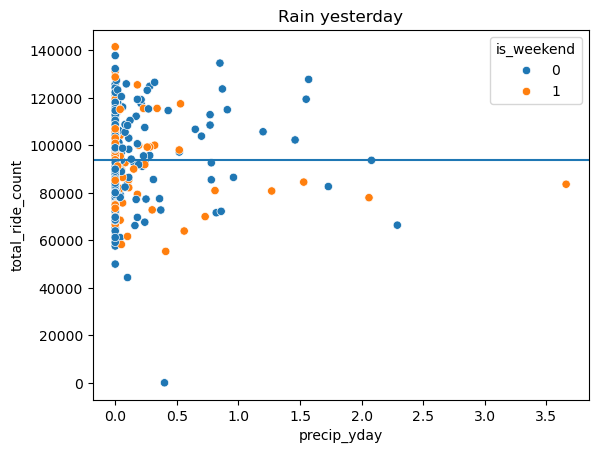

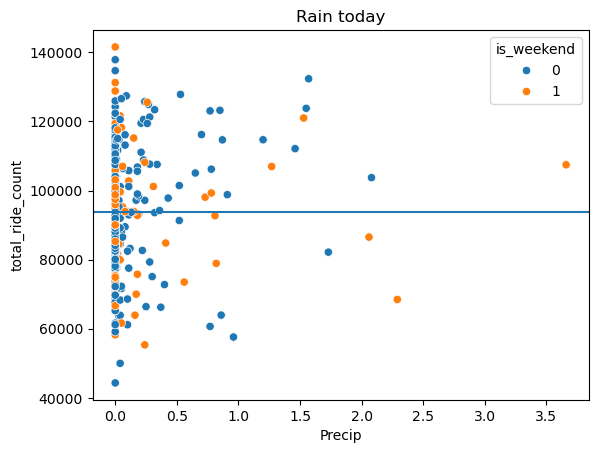

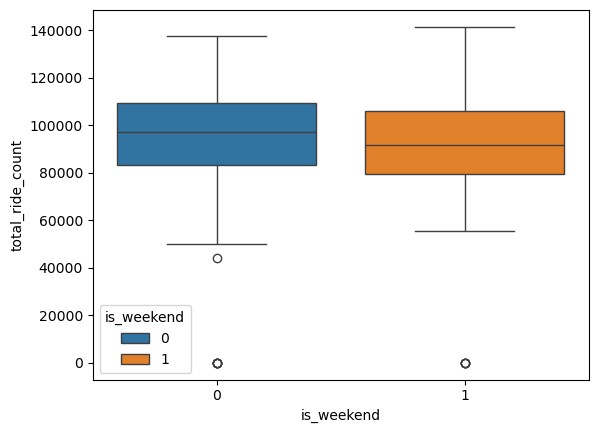

In [21]:
daily['precip_yday'] = daily['Precip'].shift(1)
daily['precip_2_days_ago'] = daily['Precip'].shift(2)
daily['precip_3_days_ago'] = daily['Precip'].shift(3)

sns.scatterplot(data=daily, x='precip_3_days_ago', y='total_ride_count', hue='is_weekend')
plt.axhline(y=daily['total_ride_count'].mean())
plt.title("Rain 3 days ago")
plt.show()

sns.scatterplot(data=daily, x='precip_2_days_ago', y='total_ride_count', hue='is_weekend')
plt.axhline(y=daily['total_ride_count'].mean())
plt.title("Rain 2 days ago")
plt.show()

sns.scatterplot(data=daily, x='precip_yday', y='total_ride_count', hue='is_weekend')
plt.axhline(y=daily['total_ride_count'].mean())
plt.title("Rain yesterday")
plt.show()

sns.scatterplot(data=daily, x='Precip', y='total_ride_count', hue='is_weekend')
plt.axhline(y=daily['total_ride_count'].mean())
plt.title("Rain today")
plt.show()

sns.boxplot(data=daily, x='is_weekend', y='total_ride_count', hue='is_weekend')
plt.show()

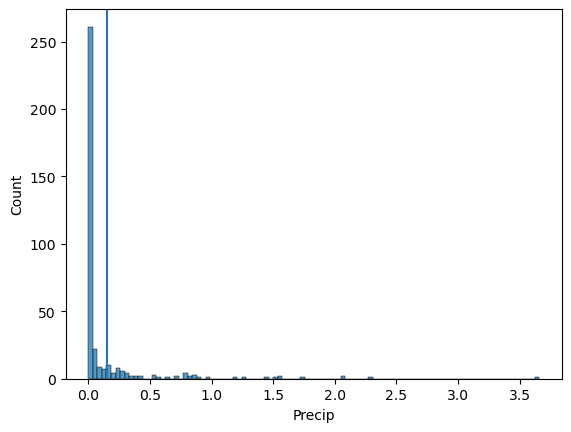

In [22]:
sns.histplot(data=daily, x='Precip', bins=100)
plt.axvline(x=0.15)
plt.show()

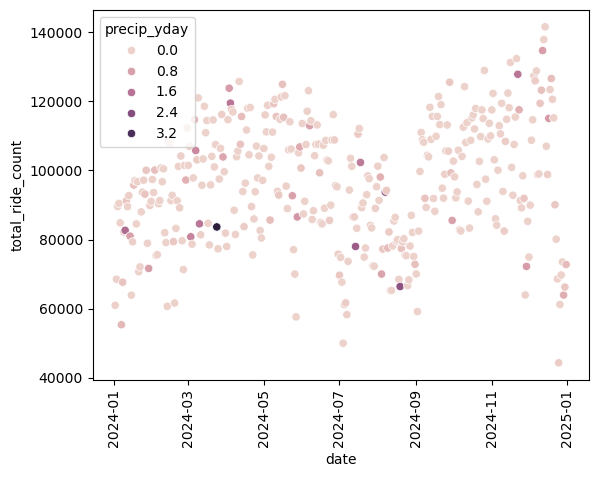

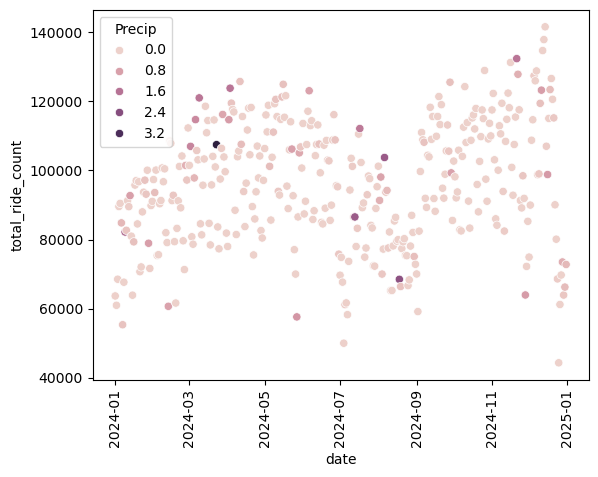

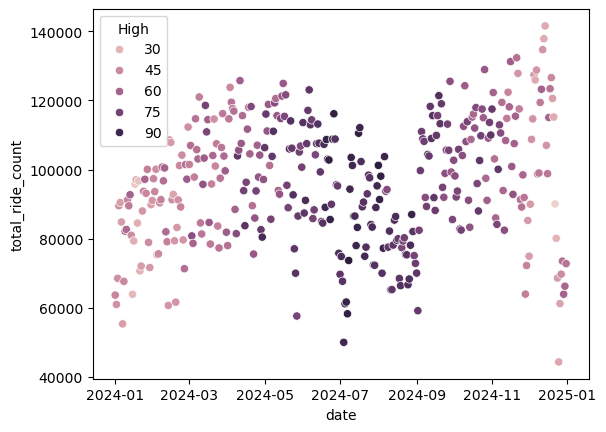

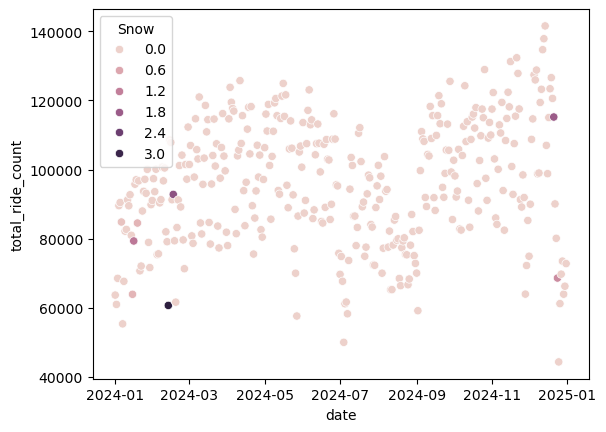

In [23]:
daily['rain_today'] = daily['Precip'] >= 0.15
daily['rain_yday'] = daily['precip_yday'] >= 0.15

sns.scatterplot(daily, x='date', y='total_ride_count', hue='precip_yday')
plt.xticks(rotation=90)
plt.show()

sns.scatterplot(daily, x='date', y='total_ride_count', hue='Precip')
plt.xticks(rotation=90)
plt.show()

sns.scatterplot(daily, x='date', y='total_ride_count', hue='High')
plt.show()

sns.scatterplot(daily, x='date', y='total_ride_count', hue='Snow')
plt.show()

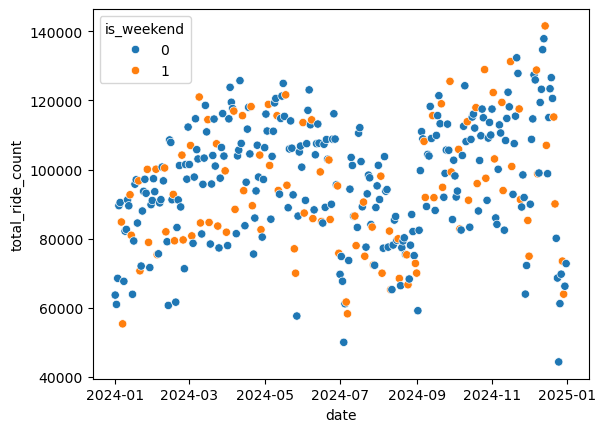

In [24]:
sns.scatterplot(data=daily, x='date', y='total_ride_count', hue='is_weekend')
plt.show()